# K-Nearest Neighbors Classification: Predicting College Admission

## Goal
In this activity, you will use **K-nearest neighbors (KNN)** to predict whether a student is admitted to a college based on two exam scores.

You will build the model yourself, then use scikit-learn to check whether your implementation reaches the same results.

By the end, you should be able to:

1. Explain how KNN makes a classification.
2. Calculate Euclidean distance.
3. Find the nearest training examples.
4. Use majority voting to predict a class.
5. Explain what the value of `k` controls.
6. Measure the model's accuracy.
7. Describe a KNN decision boundary.
8. Compare a hand-built model with a reference implementation.

## What you need to know
You only need basic Python skills:

- running notebook cells
- reading variables
- changing a small amount of code
- interpreting graphs and numbers

All required data are created inside this notebook. No files need to be downloaded.


## 1. Setup

Run the cell below. It imports the tools used in this notebook.

- **NumPy** creates and stores numerical data.
- **Matplotlib** makes graphs.
- **scikit-learn** is used only at the end to check our work.

The main KNN model will be built using NumPy.


In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Make random results repeatable.
np.random.seed(7)

print("Setup complete!")


Setup complete!


## 2. Create the data

Each student has:

- an Exam 1 score
- an Exam 2 score
- an admission result: `0` means not admitted and `1` means admitted

The code below creates a small, realistic-looking dataset. The admission results are not perfectly predictable, just like real data.


In [3]:
number_of_students = 120

exam_1 = np.random.randint(45, 101, number_of_students)
exam_2 = np.random.randint(45, 101, number_of_students)

# Higher combined scores usually mean a better chance of admission.
combined_score = exam_1 + exam_2
random_noise = np.random.normal(0, 10, number_of_students)
admitted = (combined_score + random_noise >= 145).astype(int)

# X contains the two input features. y contains the yes/no result.
X = np.column_stack((exam_1, exam_2))
y = admitted

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First five students:")
print(X[:5])
print("First five results:", y[:5])


Shape of X: (120, 2)
Shape of y: (120,)
First five students:
[[92 48]
 [49 74]
 [70 57]
 [99 57]
 [48 60]]
First five results: [0 0 0 1 0]


### Question 1

What does one row of `X` represent? What does one value of `y` represent?

**Your answer:**

One row of X is a single student's two exam scores. and one value of y is a single label, a yes/no result for one student.

## 3. Visualize the data

A scatter plot helps us see whether admitted and non-admitted students tend to have different exam scores.


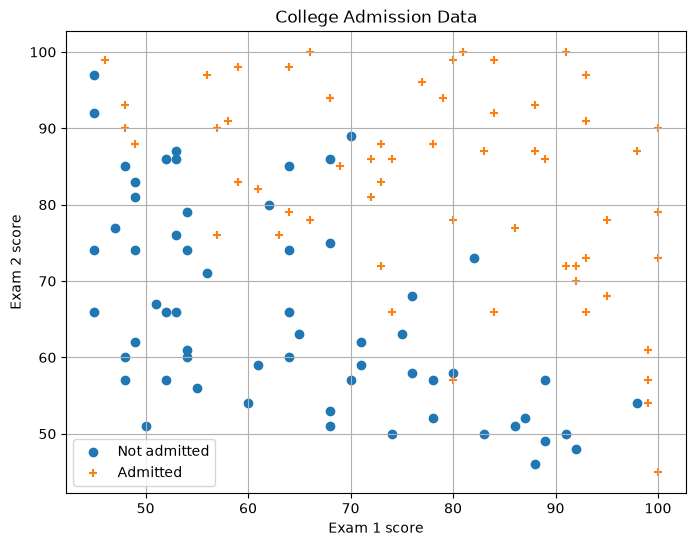

In [4]:
not_admitted = y == 0
is_admitted = y == 1

plt.figure(figsize=(8, 6))
plt.scatter(X[not_admitted, 0], X[not_admitted, 1],
            label="Not admitted", marker="o")
plt.scatter(X[is_admitted, 0], X[is_admitted, 1],
            label="Admitted", marker="+")

plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.title("College Admission Data")
plt.legend()
plt.grid(True)
plt.show()


### Question 2

Describe the pattern in the graph. Do students with higher scores appear more likely to be admitted?

**Your answer:**

Yes, especially if both scores are high.

## 4. Why K-nearest neighbors?

KNN predicts a new student's class by comparing that student with the training students.

For one new student, the algorithm:

1. Calculates the distance to every training student.
2. Selects the `k` closest students.
3. Looks at their admission results.
4. Predicts the class that appears most often.

We will use **Euclidean distance**:

$$
d = \sqrt{(x_1-a_1)^2 + (x_2-a_2)^2}
$$

Here, the two coordinates are the two exam scores.


In [5]:
def euclidean_distance(point_1, point_2):
    squared_difference = (point_1 - point_2) ** 2
    return np.sqrt(np.sum(squared_difference))

student_a = np.array([70, 80])
student_b = np.array([74, 83])

distance = euclidean_distance(student_a, student_b)

print("Student A:", student_a)
print("Student B:", student_b)
print("Euclidean distance:", round(distance, 3))


Student A: [70 80]
Student B: [74 83]
Euclidean distance: 5.0


### Question 3

If the five nearest neighbors contain three admitted students and two non-admitted students, what class will KNN predict?

**Your answer:**

Admitted, because 3 admitted > 2 non admitted.

## 5. Split the data

We will use:

- **training data** as the examples KNN searches through
- **test data** to check the model on students it has not seen before

Here, 75% of the students are used for training and 25% are used for testing.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=7,
    stratify=y
)

print("Training students:", len(X_train))
print("Testing students:", len(X_test))


Training students: 90
Testing students: 30


### Question 4

Why should we test the model on students that were not included in its training examples?

**Your answer:**

To make sure the model hasn't overfit and can generalize upon unseen data.

## 6. Build KNN ourselves

KNN does not learn weights. Its `fit()` method stores the training data.

When predicting one new student, it:

1. Calculates the distance from the new student to every training student.
2. Sorts the distances from smallest to largest.
3. Keeps the first `k` students.
4. Uses majority voting to predict the class.


### Scale the exam scores

KNN is based entirely on distance. A feature with a larger numerical scale can dominate the distance calculation.

We calculate the mean and standard deviation from the **training data only**, then use those same values for both the training and test data.


In [7]:
feature_mean = X_train.mean(axis=0)
feature_std = X_train.std(axis=0)

X_train_scaled = (X_train - feature_mean) / feature_std
X_test_scaled = (X_test - feature_mean) / feature_std

print("Mean of scaled training data:",
      np.round(X_train_scaled.mean(axis=0), 3))
print("Standard deviation of scaled training data:",
      np.round(X_train_scaled.std(axis=0), 3))


Mean of scaled training data: [0. 0.]
Standard deviation of scaled training data: [1. 1.]


### How prediction works

For one new point $x$, calculate its distance to every training point $x_i$:

$$
d_i = \sqrt{\sum_j (x_j-x_{ij})^2}
$$

Sort the distances and keep the indices of the `k` smallest values.

For binary classification, the predicted probability of admission is the fraction of those neighbors whose label is `1`:

$$
P(y=1) = \frac{\text{number of admitted neighbors}}{k}
$$

The final prediction is `1` when at least half of the neighbors are admitted.


In [8]:
class MyKNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        # KNN training only stores the examples.
        self.X_train = X
        self.y_train = y
        return self

    def _neighbor_labels(self, new_student):
        # Step 1: calculate the distance to every training student.
        differences = self.X_train - new_student
        distances = np.sqrt(np.sum(differences ** 2, axis=1))

        # Step 2: sort the distances from smallest to largest.
        sorted_indices = np.argsort(distances)

        # Step 3: keep the k nearest training students.
        nearest_indices = sorted_indices[:self.k]
        neighbor_labels = self.y_train[nearest_indices]

        return neighbor_labels

    def predict_proba(self, X):
        probabilities = []

        for new_student in X:
            neighbor_labels = self._neighbor_labels(new_student)

            # Step 4: the fraction of neighbors in class 1.
            admission_probability = np.mean(neighbor_labels == 1)
            probabilities.append(
                [1 - admission_probability, admission_probability]
            )

        return np.array(probabilities)

    def predict(self, X):
        admission_probability = self.predict_proba(X)[:, 1]
        return (admission_probability >= 0.5).astype(int)


class MyKNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        # TODO 1: Store the training features and labels.
        self.X_train = ...
        self.y_train = ...
        return self

    def _neighbor_labels(self, new_student):
        # TODO 2: Subtract the new student from every training student.
        differences = self.X_train - new_student

        # TODO 3: Calculate one Euclidean distance per training student.
        distances = np.sqrt(np.sum(self.X_train ** 2, self.y_train ** 2, axis=1))

        # TODO 4: Sort the distances from smallest to largest.
        sorted_indices = ...

        # TODO 5: Keep only the first k indices.
        nearest_indices = ...

        # TODO 6: Use those indices to retrieve the neighbor labels.
        neighbor_labels = ...

        return neighbor_labels

    def predict_proba(self, X):
        probabilities = []

        for new_student in X:
            neighbor_labels = self._neighbor_labels(new_student)

            # TODO 7: Find the fraction of neighbor labels equal to 1.
            admission_probability = ...

            probabilities.append(
                [1 - admission_probability, admission_probability]
            )

        return np.array(probabilities)

    def predict(self, X):
        admission_probability = self.predict_proba(X)[:, 1]

        # TODO 8: Predict class 1 when the probability is at least 0.5.
        return ...


### Fill-in hints

You may use:

```python


np.argsort(...)
sorted_indices[:self.k]
self.y_train[nearest_indices]
np.mean(neighbor_labels == 1)
(admission_probability >= 0.5).astype(int)
```

Each expression is used once.


## 7. Fit the model

The value of `k` controls how many neighbors vote.

- A very small `k` can make the model sensitive to individual training points.
- A larger `k` produces a smoother, more stable decision.


In [9]:
model = MyKNN(k=5)
model.fit(X_train_scaled, y_train)

print("The model has stored the training data.")
print("Number of stored students:", len(model.X_train))
print("k:", model.k)


The model has stored the training data.
Number of stored students: 90
k: 5


### Inspect one set of neighbors

The cell below finds the five nearest training students for the first test student.


In [10]:
first_test_student = X_test_scaled[0]

differences = model.X_train - first_test_student
distances = np.sqrt(np.sum(differences ** 2, axis=1))
nearest_indices = np.argsort(distances)[:model.k]

print("First test student:", X_test[0])
print("Nearest training students:")
print(X_train[nearest_indices])
print("Neighbor labels:", y_train[nearest_indices])


First test student: [70 89]
Nearest training students:
[[73 88]
 [72 86]
 [68 86]
 [69 85]
 [74 86]]
Neighbor labels: [1 1 0 1 1]


### Question 6

How many of the nearest neighbors were admitted? Based on majority voting, what class should the model predict?

**Your answer:**

4 of the nearest neighbors were admitted, and because 4 out of 5 represents a majority, the model should predict the admitted class.

## 8. Make predictions

`predict()` gives a final class, either `0` or `1`.

`predict_proba()` gives the fraction of nearest neighbors in each class.


In [11]:
predicted_classes = model.predict(X_test_scaled)
predicted_probabilities = model.predict_proba(X_test_scaled)

print("First five test students:")
print(X_test[:5])
print()
print("Predicted classes:", predicted_classes[:5])
print("Fraction of neighbors admitted:",
      np.round(predicted_probabilities[:5, 1], 3))
print("Actual results:", y_test[:5])


First five test students:
[[70 89]
 [64 74]
 [45 92]
 [92 70]
 [59 98]]

Predicted classes: [1 1 1 1 1]
Fraction of neighbors admitted: [0.8 0.6 0.8 0.8 1. ]
Actual results: [0 0 0 1 1]


### Question 7

For the first test student, compare the neighbor fraction, predicted class, and actual result. Was the model correct?

**Your answer:**

The model was correct for two out of the five test students, but KNN was incorrect for the first 3. 

## 9. Evaluate the model

Accuracy is the fraction of predictions that are correct.

A confusion matrix counts four types of results:

- true negatives: correctly predicted not admitted
- false positives: predicted admitted, but actually not admitted
- false negatives: predicted not admitted, but actually admitted
- true positives: correctly predicted admitted


In [12]:
accuracy = accuracy_score(y_test, predicted_classes)
matrix = confusion_matrix(y_test, predicted_classes)

print("Accuracy:", round(accuracy, 3))
print("Accuracy as a percent:", round(accuracy * 100, 1), "%")
print()
print("Confusion matrix:")
print(matrix)


Accuracy: 0.767
Accuracy as a percent: 76.7 %

Confusion matrix:
[[10  5]
 [ 2 13]]


### Question 8

1. What percent of the test predictions were correct?
2. How many test students were classified incorrectly?

Hint: the incorrect predictions are the two off-diagonal values in the confusion matrix.

**Your answer:**

76.7% of the predictions were correct and 7 students were classified incorrectly


## 10. Check our work with scikit-learn

Now we will train scikit-learn's KNN classifier using the exact same training data, test data, scaling, and value of `k`.

Because both implementations use the same algorithm, their predictions should match.


In [13]:
reference_model = KNeighborsClassifier(n_neighbors=5)
reference_model.fit(X_train_scaled, y_train)

reference_classes = reference_model.predict(X_test_scaled)
reference_probabilities = reference_model.predict_proba(X_test_scaled)

reference_accuracy = accuracy_score(y_test, reference_classes)
prediction_agreement = np.mean(
    predicted_classes == reference_classes
)
average_probability_difference = np.mean(
    np.abs(
        predicted_probabilities[:, 1]
        - reference_probabilities[:, 1]
    )
)

print("Our model accuracy:",
      round(accuracy, 3))
print("scikit-learn accuracy:",
      round(reference_accuracy, 3))
print("Prediction agreement:",
      round(prediction_agreement * 100, 1), "%")
print("Average probability difference:",
      round(average_probability_difference, 4))


Our model accuracy: 0.767
scikit-learn accuracy: 0.767
Prediction agreement: 100.0 %
Average probability difference: 0.0


### Question 9

Do the two implementations produce the same accuracy and predictions?

Would you consider the hand-built implementation successful? Explain.

**Your answer:**

Yes they have the same accuracy and agree 100% on the predictions. Yes, I'd consider it successful.

## 11. Try your own student

Change the two exam scores below, then run the cell.

New students must be scaled using the same mean and standard deviation that were calculated from the training data.


In [19]:
student_exam_1 = 50
student_exam_2 = 75

new_student = np.array([[student_exam_1, student_exam_2]])
new_student_scaled = (
    new_student - feature_mean
) / feature_std

admission_probability = model.predict_proba(
    new_student_scaled
)[0, 1]
predicted_result = model.predict(
    new_student_scaled
)[0]

print("Fraction of nearest neighbors admitted:",
      round(admission_probability * 100, 1), "%")
print("Predicted class:", predicted_result)

if predicted_result == 1:
    print("Prediction: admitted")
else:
    print("Prediction: not admitted")


Fraction of nearest neighbors admitted: 0.0 %
Predicted class: 0
Prediction: not admitted


### Question 10

Try at least three pairs of exam scores. Record the results below.

| Exam 1 | Exam 2 | Fraction of neighbors admitted | Predicted class |
|---:|---:|---:|---:|
| 90 | 60 | 60.0% | 1 |
| 90 | 90 | 100.0%| 1 |
| 50 | 75 | 0.0%  | 0 |

What pattern do you notice?

**Your answer:**

Students with scores on the higher end for both exams are more likely to be admitted. 


## 12. Plot the decision boundaries

A **decision boundary** is where a model changes from predicting class `0` to predicting class `1`.

KNN boundaries can bend around groups of training points because the prediction depends on nearby examples rather than one straight equation.

The solid line is the boundary from our model. The dashed line is the boundary from scikit-learn.


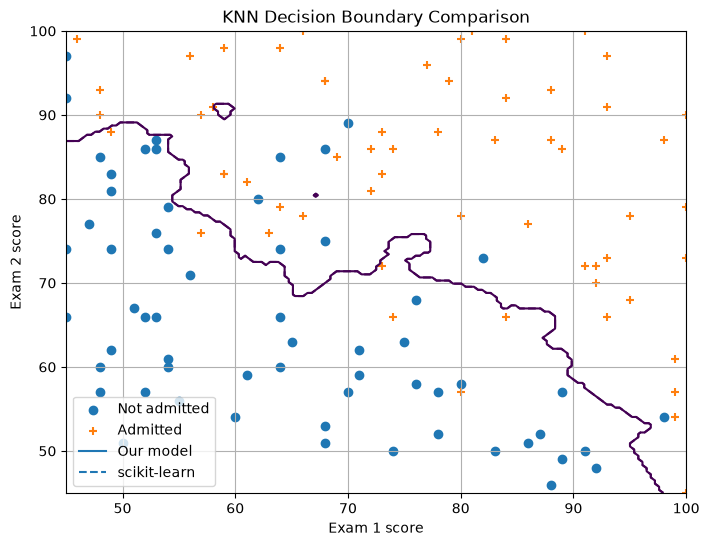

In [20]:
from matplotlib.lines import Line2D

# Create a grid of possible exam-score pairs.
exam_1_grid = np.linspace(45, 100, 150)
exam_2_grid = np.linspace(45, 100, 150)
grid_x, grid_y = np.meshgrid(
    exam_1_grid,
    exam_2_grid
)

grid_points = np.column_stack(
    (grid_x.ravel(), grid_y.ravel())
)
grid_points_scaled = (
    grid_points - feature_mean
) / feature_std

our_grid_class = model.predict(
    grid_points_scaled
).reshape(grid_x.shape)

reference_grid_class = reference_model.predict(
    grid_points_scaled
).reshape(grid_x.shape)

plt.figure(figsize=(8, 6))
plt.scatter(
    X[not_admitted, 0],
    X[not_admitted, 1],
    label="Not admitted",
    marker="o"
)
plt.scatter(
    X[is_admitted, 0],
    X[is_admitted, 1],
    label="Admitted",
    marker="+"
)

plt.contour(
    grid_x,
    grid_y,
    our_grid_class,
    levels=[0.5],
    linestyles="-"
)
plt.contour(
    grid_x,
    grid_y,
    reference_grid_class,
    levels=[0.5],
    linestyles="--"
)

handles, labels = plt.gca().get_legend_handles_labels()
boundary_handles = [
    Line2D([0], [0], linestyle="-",
           label="Our model"),
    Line2D([0], [0], linestyle="--",
           label="scikit-learn")
]
plt.legend(handles=handles + boundary_handles)

plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.title("KNN Decision Boundary Comparison")
plt.grid(True)
plt.show()


### Question 11

1. What does each decision boundary separate?
2. Do the two boundary lines overlap?
3. Why is the KNN boundary less straight than a logistic regression boundary?
4. Why might some data points appear on the "wrong" side of the boundary?

**Your answer:**

1. The decision boundaries separate the non-admitted students from the admitted students.
2. Yes, they overlap completely.
3. KNN classifies new points based on their proximity to other points, while logistic regression models a global linear boundary.
4. The KNN model doesn't have a 100% accuracy, although it can generalize on new points for the most part.


## 13. Final reflection

Answer each question in one or two sentences.

1. How does KNN classify a new student?
2. What does `k` control?
3. Why is scaling important for KNN?
4. What is the difference between the neighbor fraction and the predicted class?
5. Why did we compare our model with scikit-learn?
6. Does high accuracy prove that a model will always be correct? Explain.

**Your answer:**

1. KNN classifies a new student based on its proximity (using Euclidean distance) to a set number of its nearest neighbors, and depending on the classes in which the neighbors landed up, KNN takes the class with the majority of the neighbors and assigns it to the new point.
2. K controls the number of nearest neighbors that the algorithm finds to be in one class or the other to see if the test point is in either one of these classes.
3. KNN relies on distance metrics, so large numerical ranges without scaling can inflate the distance metric wrongly.
4. The neighbor fraction is the model's confidence that the test point is in a certain class and the predicted classes is the definitive category assigned to the point.
5. No, as high accuracy can be an indicator that the model overfit on its training and can't generalize. 


## Optional challenge: compare different values of k

Run the cell below and compare several values of `k`.

Look at:

- test accuracy
- how smooth or irregular the decision boundary becomes
- whether a very small or very large `k` performs best

What happens when `k = 1`? What happens when `k` becomes much larger?


In [ ]:
k_values = [1, 3, 5, 9, 15, 25]

for k in k_values:
    test_model = MyKNN(k=k)
    test_model.fit(X_train_scaled, y_train)
    test_predictions = test_model.predict(X_test_scaled)
    test_accuracy = accuracy_score(y_test, test_predictions)

    print("k =", str(k).rjust(2),
          "| accuracy =", round(test_accuracy, 3))
